---
# Lyapunov Exponent - Heterogeneous RNN
---

## Imports

In [198]:
# Standard library
import os, re, glob, time, gc, random, copy, tempfile, uuid, pickle, json, socket, sys
from itertools import product
from copy import deepcopy
from tqdm import tqdm

# Core scientific stack
import numpy as np
import numba as nb
import pandas as pd
import torch
from torch import tensor
import math
import scipy
from math import gamma
from scipy.stats import gamma as gamma_dist
from scipy.stats import pearsonr
import scipy.signal as signal
from statsmodels.tsa.stattools import acf
from scipy.special import gammaln
from pylab import *

# Parallelization
from joblib import Parallel, delayed

# Plotting
import matplotlib as mpl
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap, SymLogNorm
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.patches as patches
from matplotlib.patches import Rectangle

# Scientific / ML
from scipy.integrate import solve_ivp, simpson
from scipy.signal import correlate
from numpy.polynomial.hermite import hermgauss
from numpy.linalg import eigh
from sklearn.linear_model import Ridge, LinearRegression
from scipy.signal import welch, get_window
from scipy.optimize import root_scalar, fsolve
from scipy.interpolate import griddata

## Plotting Utils

In [70]:
# Set default Style for plotting
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False

#tableau for plots
plt.style.use('tableau-colorblind10')
#colormap
cmap = plt.get_cmap('Blues')
#set plot size
plt.rcParams["figure.autolayout"] = True
plt.rcParams['font.size'] = 10   # Default font size for text
plt.rcParams['axes.titlesize'] = 10   # Font size for axes titlese
plt.rcParams['axes.labelsize'] = 10 # Font size for x and y labels
plt.rcParams['xtick.labelsize'] = 9 # Font size for x tick labels
plt.rcParams['ytick.labelsize'] = 9 # Font size for y tick labels
#print(plt.style.available)


#set-up the font as in latex
plt.rcParams.update({
    "font.size": 10,
    "font.family": "serif",
    "font.serif": "cmr10",
    "mathtext.fontset": "cm",
    "axes.formatter.use_mathtext": True
})

my_palettes = {'1':['#B3D69B', '#455D51', '#D8C27A', '#42AD70', '#284229', '#93CB5B'],
               '2':['#B28CF0', '#F6A3B1', '#8CCCF0', '#F6BB37', '#F3B3B4', '#36B7D2'],
               '3':['#29B4B0', '#F6753C', '#3CAF71', '#F2C12E'],
               '4':['#EF5840', '#187060', '#6EB0C6', '#F2A900'],
               '5':['#4D7B7A', '#9B83C5', '#B2ACA7', '#E07A5F'],
               '6':['#C46CE8', '#1A63E0', '#6EE4D6', '#F2A03D'],
               '7':['#F04C45', '#FAD25A', '#F08FB5', '#498DC4'],
               '8':['#E14E2D', '#EBAF29', '#498DC4', '#76C893'],
               '9':['#6B8BD4', '#FD5A40', '#45742D', '#F2A900'],
               '10':['#D64444', '#FFBEA8', '#43A4C4', '#42708F'],
               }


def plot_dynamics(x, t=None, dt=0.1, n_plot=10, N=None, title=None, cmap='Blues', label=None):
    '''
    Plot dynamics of the RNN (subset of neuron trajectories over time)
    '''
    time_steps = x.shape[1]
    N = x.shape[0]

    # Build time axis if not provided
    if t is None: 
        t = np.arange(0, int(time_steps * dt), dt)

    # Select random neuron indices to display
    random_indices = np.random.choice(N, size=n_plot, replace=False)
    selected_trajectories = x[random_indices, :]

    # Choose colors from a seaborn palette
    colors = sns.color_palette(cmap, n_plot)

    # Plot trajectories
    for i in range(n_plot):
        plt.plot(t, selected_trajectories[i, :], lw=1.5, color=colors[i], label=label if i == 0 else None)

    # Optional title
    if title:
        plt.title(title)
    
    plt.xlabel('Time (ms)')
    plt.ylabel('x(t)')

    # Set y-limits based on plotted traces
    ymin = np.round(np.min(selected_trajectories), 1)
    ymax = np.round(np.max(selected_trajectories), 1)
    plt.ylim(ymin, ymax)

## RNN Model

In [24]:
# Define the RNN model class
class RNN_Model:

    def __init__(self, mu=0, g=0.5, set_selfcoupling=False, s=0.0, gamma=0, N=100, T=500, dt=None, J=None, A=None, tau_x=1.0, k_x=1.0, tau_p=1.0, p=0, K=1,
                 k_min=1, k_max=300, alpha=1, mu_ln=3, sig_ln=1, activation='tanh', distribution='poisson'):
        '''
        Initialize the parameters of the model
        '''
        # Store parameters and build matrices (A, J, W)
        self.set_parameters(mu=mu, g=g, set_selfcoupling=set_selfcoupling, s=s, gamma=gamma, N=N, T=T, dt=dt, J=J, A=A, tau_x=tau_x, k_x=k_x, tau_p=tau_p, p=p, K=K,
                            k_min=k_min, k_max=k_max, alpha=alpha, mu_ln=mu_ln, sig_ln=sig_ln, activation=activation, distribution=distribution)

    def set_parameters(self, mu=None, g=None, set_selfcoupling=None, s=None, gamma=None, N=None, T=None, dt=None, J=None, A=None, tau_x=None, k_x=None, tau_p=None, p=None, K=None,
                       k_min=None, k_max=None, alpha=None, mu_ln=None, sig_ln=None, activation=None, distribution=None):
        '''
        Set the parameters of the model
        '''
        # Basic scalar parameters
        if mu is not None:
            self.mu = mu
        if g is not None:
            self.g = g
        if set_selfcoupling is not None:
            self.set_selfcoupling = set_selfcoupling
        if s is not None:
            self.s = s
        if gamma is not None:
            self.gamma = gamma
        if N is not None:
            self.N = N
        if T is not None:
            self.T = T
        if dt is not None:
            self.dt = dt
        if tau_x is not None:
            self.tau_x = tau_x
        if k_x is not None:
            self.k_x = k_x
        if tau_p is not None:
            self.tau_p = tau_p
        if p is not None:
            self.p = p
        if activation is not None:
            self.activation = activation
        if distribution is not None:
            self.distribution = distribution
        if k_min is not None:
            self.k_min = k_min
        if k_max is not None:
            self.k_max = k_max
        if alpha is not None:
            self.alpha = alpha
        if mu_ln is not None:
            self.mu_ln = mu_ln
        if sig_ln is not None: 
            self.sig_ln = sig_ln

        # Set mean degree K depending on the degree distribution
        if K is not None:
            if self.distribution == 'poisson':
                self.K = K
            elif self.distribution == 'power_law':
                _, self.K, _ = self.g_critical_power_law()
            elif self.distribution == 'log_normal':
                self.K = np.exp(self.mu_ln + self.sig_ln**2 / 2)
            elif self.distribution == 'full':
                self.K = self.N

        # Build adjacency matrix A (sample if not provided)
        self.A = self.sample_adjacency_matrix() if A is None else A
        # Effective mean degree from adjacency
        self.K_eff = np.mean(np.sum(self.A, axis=1))
        
        # Build interaction matrix J (sample if not provided)
        if self.gamma == 0:
            self.J = np.random.normal(0, self.g / np.sqrt(self.K_eff), size=(self.N, self.N)) if J is None else J
        else:
            self.J = self.sample_interaction_matrix() if J is None else J

        # Effective connectivity matrix
        self.W = self.J * self.A
        # Optional self-coupling on the diagonal
        if self.set_selfcoupling:
            np.fill_diagonal(self.W, self.s)

    def g_critical_power_law(self):
        ''''
        Useful quantities for the power-law distribution
        '''
        # Normalization constant of truncated power law
        norm = (1 - self.alpha) / (self.k_max**(1 - self.alpha) - self.k_min**(1 -self.alpha))
        # First moment E[k]
        mean = norm * (self.k_max**(2 - self.alpha) - self.k_min**(2 - self.alpha)) / (2 - self.alpha) 
        # Second moment E[k^2]
        second_moment = norm * (self.k_max**(3 - self.alpha) - self.k_min**(3 - self.alpha)) / (3 - self.alpha)  
        # Critical coupling estimate
        g_crit = np.sqrt(mean**2 / second_moment)

        return g_crit, mean, second_moment
    
    def generate_degree_sequence(self):
        '''
        Generate a degree sequence based on the specified distribution
        '''
        # Sample degrees k_i from the chosen distribution
        if self.distribution == 'poisson':
            k = np.random.poisson(self.K, self.N)
        elif self.distribution == 'power_law':
            u = np.random.rand(self.N)
            k = (self.k_min**(1 - self.alpha) + u * (self.k_max**(1 - self.alpha) - self.k_min**(1 - self.alpha)))**(1 / (1 - self.alpha))
        elif self.distribution == 'log_normal':
            k = np.random.lognormal(mean=self.mu_ln, sigma=self.sig_ln, size=self.N)
        elif self.distribution == 'full':
            k = np.ones(self.N) * self.N
        else:
            raise ValueError('Unsupported distribution type')
                                                             
        return k
        
    def evaluate_p(self, k):
        '''
        Calculate the probability matrix for connection between nodes based on degrees.
        '''
        # Connection probabilities p_ij = k_i k_j / (N K)
        p = np.outer(k, k) / (self.N * self.K)
        return p
    
    def sample_adjacency_matrix(self):
        '''
        Sample a symmetric binary adjacency matrix.
        '''
        # Sample degrees and corresponding connection probabilities
        k = self.generate_degree_sequence()
        p = self.evaluate_p(k)     
        # Bernoulli sampling for edges
        A = np.random.rand(self.N, self.N) < p
        # Keep only upper triangle and symmetrize
        A = np.triu(A, 1) 
        A = A + A.T 
        return A.astype(int)
    
    def sample_interaction_matrix(self):
        '''
        Sample the interaction matrix with gamma
        '''
        # Independent Gaussian matrices
        z1 = np.random.normal(size=(self.N, self.N))
        z2 = np.random.normal(size=(self.N, self.N))

        # Upper and lower triangle entries with correlation controlled by gamma
        upper = self.mu/self.N + self.g/np.sqrt(self.K_eff) * z1
        lower = self.mu/self.N + self.g/np.sqrt(self.K_eff) * (self.gamma * z1 + np.sqrt(1 - self.gamma**2) * z2)

        # Fill asymmetric matrix using upper and lower parts
        triu_idx = np.triu_indices(self.N, k=1)
        mat = np.zeros((self.N, self.N))
        mat[triu_idx] = upper[triu_idx]
        mat[(triu_idx[1], triu_idx[0])] = lower[triu_idx]

        return mat
    
    def phi(self, x):
        '''
        Activation function
        '''
        # Apply selected nonlinearity
        if self.activation == 'tanh':
            return np.tanh(x)
        elif self.activation == 'linear':
            return x
        elif self.activation == 'logistic':
            return 1 / (1 + np.exp(-x))
        else:
            raise ValueError('Unsupported activation function')
        
    def phi_prime(self, x):
        '''
        Derivative of the activation function
        '''
        # Derivative of selected nonlinearity
        if self.activation == 'linear':
            return np.ones_like(x)
        elif self.activation == 'tanh':
            return 1 - np.tanh(x)**2
        elif self.activation == 'logistic':
            return np.exp(-x) / (1 + np.exp(-x))**2
        else:
            raise ValueError('Unsupported activation function')
        
    def compute_jacobian(self, x_jac=None):
        '''
        Compute the Jacobian matrix of the RNN dynamics
        '''
        N = self.N
        # Default evaluation point
        if x_jac is None:
            x_jac = np.zeros(self.N)
            
        # Jacobian: -I + W * diag(phi'(x))
        phi_prime_jac = self.phi_prime(x_jac)
        diag_phi_prime = np.diag(phi_prime_jac)
        Jac = -np.eye(N) + self.W @ diag_phi_prime
        # Eigen-decomposition of Jacobian
        eigval_Jac, eigvec_Jac = np.linalg.eig(Jac)

        return eigval_Jac, eigvec_Jac
        
    def rnn_dynamics(self, t, x):
        '''
        Compute the RNN dynamics
        '''
        # Continuous-time RNN ODE
        phi_x = self.phi(x)
        xdot = (1 / self.tau_x) * (-self.k_x * x + self.W @ phi_x)
        return xdot    
    
    def simulate_RNN(self):
        '''
        Simulate the RNN using solve_ivp
        '''
        # Random initial condition
        x0 = np.random.normal(0, 1, size=(self.N,)) # * 1e-1

        # Integrate ODE with or without fixed evaluation grid
        if self.dt is None:
            sol = solve_ivp(self.rnn_dynamics, [0, self.T], x0, method='RK45')
        else:
            t_eval = np.arange(0, self.T, self.dt)
            sol = solve_ivp(self.rnn_dynamics, [0, self.T], x0, method='RK45', t_eval=t_eval)
        return sol.y, sol.t

# Lyapunov Exponents

In [44]:
# compute condition number of a matrix
def _cond_number(A):
        s = torch.linalg.svdvals(A)
        smin = torch.clamp_min(s.min(), torch.finfo(A.dtype).eps)
        return (s.max() / smin).item()

def rate_Lyapunov_spectra_torch(N, g, W, dt, tSim, nLE, tONS, seedIC, seedNet, seedONS, 
                                dns=False, plots=False, device=None, dtype=torch.float64, verbose=False, chunk_size=None):
    '''
    Pytorch implementation of Lyapunov spectrum calculation for rate networks.
    '''
    if device is None:
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
    device = torch.device(device)

    tstart = time.time()
    assert nLE <= N, 'number of Lyapunov exponents have to be smaller than N'
    assert nLE > 0, 'number of Lyapunov exponents has to be larger than 0'
    assert dt <= 1, 'time discretization has to be smaller/equal than 1'
    assert tONS <= tSim, 'ONS interval has to be smaller than simulation time'
    assert dt <= tONS, 'dt has to be less than or equal to ONS interval'
    if tONS > 10:
        print('WARNING: ONS interval might lead to ill-conditioned result')

    stepDisplay = 1000
    nStepTransient = math.ceil(1000 / dt)

    nStep = math.ceil(tSim / dt)
    nstepONS = math.ceil(tONS / dt)
    nStepTransientONS = math.ceil(nStep / 10)
    nONS = math.ceil((nStepTransientONS + nStep) / nstepONS) - 1

    total_steps = nStep + nStepTransient + nStepTransientONS

    torch.manual_seed(seedNet)
    if W is not None:
        if isinstance(W, np.ndarray):
            J = torch.from_numpy(W).to(device=device, dtype=dtype).clone()
        elif isinstance(W, torch.Tensor):
            J = W.to(device=device, dtype=dtype).clone()
        else:
            raise TypeError("W should be np.ndarray or torch.Tensor")
    else:
        J = g * torch.randn((N, N), dtype=dtype, device=device) / math.sqrt(N)
        J.fill_diagonal_(0.0)

    torch.manual_seed(seedONS)
    q, r = torch.linalg.qr(torch.randn((N, nLE), dtype=dtype, device=device))

    LS = torch.zeros(nLE, dtype=dtype, device=device)
    t = 0.0
    Ddiag = torch.eye(N, dtype=dtype, device=device) * (1 - dt)
    LSall = torch.zeros((nONS, nLE), dtype=dtype, device=device)
    normdhAll = torch.zeros(nONS, dtype=dtype, device=device) if dns else None
    printCondQ = True
    pAll = torch.zeros(nONS, dtype=dtype, device=device)
    lsidx = -1

    if chunk_size is None:
        h = torch.zeros((N, total_steps), dtype=dtype, device=device)

        # Initial conditions
        torch.manual_seed(seedIC)
        h[:, 0] = torch.randn((N,), dtype=dtype, device=device) * g

        # DNS (largest LE via brute force)
        if dns:
            pertSz = torch.tensor(1e-6, dtype=dtype, device=device)
            q_norm = torch.linalg.norm(q[:, 0])
            hPert = h[:, 0] + pertSz * q[:, 0] / q_norm
            LambdaMaxDNSall = []
        else:
            pertSz = None
            hPert = None
            LambdaMaxDNSall = None

        # Simulation
        with torch.no_grad():
            for n in range(total_steps - 1):
                # Dynamics
                h[:, n+1] = h[:, n] * (1 - dt) + (J @ torch.tanh(h[:, n])) * dt
                if dns:
                    hPert = hPert * (1 - dt) + (J @ torch.tanh(hPert)) * dt  # type: ignore

                if (n + 1 > nStepTransient):
                    hsechdt = dt / torch.cosh(h[:, n])**2
                    D = Ddiag + J * hsechdt.unsqueeze(0)
                    q = D @ q

                    if ((n + 1) % nstepONS) == 0:
                        if printCondQ:
                            c = _cond_number(q)
                            if verbose:
                                print('log10 of cond(q): ', round(math.log10(c), 2))
                            printCondQ = False

                        q, r = torch.linalg.qr(q)
                        if nLE == 1:
                            q4 = q * q * q * q
                            q4 = q4.squeeze(1)
                        else:
                            q1 = q[:, 0]
                            q4 = q1 * q1 * q1 * q1

                        lsidx += 1
                        pAll[lsidx] = 1.0 / torch.sum(q4)

                        diag_r = torch.diagonal(r).abs()
                        LSall[lsidx, :] = torch.log(diag_r) / (nstepONS * dt)

                        if n + 1 > nStepTransientONS + nStepTransient:
                            LS += torch.log(diag_r)
                            t += nstepONS * dt

                if dns:
                    dh = hPert - h[:, n+1]
                    normdh = torch.linalg.norm(dh)
                    if ((n + 1) % nstepONS) == 0:
                        hPert = h[:, n+1] + dh * (pertSz / normdh)
                        if n + 1 > nStepTransient:
                            normdhAll[lsidx] = normdh

        # Spectrum
        Lspectrum = LS / t if t > 0 else LS * float('nan')

        if dns:
            if normdhAll is not None and pertSz is not None:
                LambdaMaxDNS = torch.sum(torch.log(normdhAll / pertSz)) / ((nStep + nStepTransientONS) * dt)
                LambdaMaxDNSall = torch.log(normdhAll / pertSz) / (nstepONS * dt)
            else:
                LambdaMaxDNS = None
                LambdaMaxDNSall = None
        else:
            LambdaMaxDNS = None
            LambdaMaxDNSall = None

        # Plots
        if plots:
            H = h[:, :].detach().cpu().numpy()
            LSALL = LSall.detach().cpu().numpy()
            PALL = pAll.detach().cpu().numpy()
            if dns and LambdaMaxDNSall is not None:
                LMDNSALL = LambdaMaxDNSall.detach().cpu().numpy()
            else:
                LMDNSALL = None

            plt.subplot(221)
            plt.plot(dt * np.arange(H.shape[1]), H[0:3, :].T)
            plt.title('example activity')
            plt.ylabel('$x_i$'); plt.xlabel(r'Time ($\\tau$)')
            plt.xlim(0, dt * H.shape[1])

            plt.subplot(223)
            plt.plot(1.0 * np.arange(nLE) / nLE, Lspectrum.detach().cpu().numpy(), '.k')
            plt.plot(1.0 * np.arange(nLE) / N, np.zeros(nLE), ':', color=[0.5, 0.5, 0.5])
            plt.ylabel(r'$\\lambda_i (1/\\tau)$'); plt.xlabel(r'$i/N$')
            plt.title("Lyapunov exponents")

            plt.subplot(222)
            plt.plot(np.arange(nONS) * nstepONS * dt, LSALL[:, 0], 'k')
            if dns and LMDNSALL is not None:
                timeDNS = np.arange(nONS) * nstepONS * dt
                plt.plot(timeDNS, LMDNSALL, '--r', label='direct numerical simulations')
                plt.legend(loc='best')
            plt.xlabel(r'Time ($\\tau$)'); plt.ylabel('$\\lambda_i^{local}$')
            plt.title('first local Lyapunov exponent')
            plt.xlim(0, nONS * nstepONS * dt)

            plt.subplot(224)
            plt.plot(np.arange(nONS)*nstepONS*dt, PALL[:], 'k')
            plt.xlabel(r'Time ($\\tau$)'); plt.ylabel('P')
            plt.title('participation ratio')
            plt.xlim(0, nONS * nstepONS * dt)

            plt.tight_layout()
            plt.show()

        tend = time.time()
        if verbose:
            print(tend - tstart, 'sec elapsed')

        # Convert to CPU/NumPy
        Lspectrum_np = Lspectrum.detach().cpu().numpy()
        LSall_np = LSall.detach().cpu().numpy()
        pAll_np = pAll.detach().cpu().numpy()
        if dns:
            LambdaMaxDNS_np = None if LambdaMaxDNS is None else float(LambdaMaxDNS.detach().cpu().numpy())
            LambdaMaxDNSall_np = None if LambdaMaxDNSall is None else LambdaMaxDNSall.detach().cpu().numpy()
            return Lspectrum_np, LSall_np, pAll_np, LambdaMaxDNS_np, LambdaMaxDNSall_np
        else:
            return Lspectrum_np, LSall_np, pAll_np

    # ------------------------------------
    # Chunked modality: streaming CPU/GPU 
    # ------------------------------------
    if plots:
        h_cpu = torch.zeros((N, total_steps), dtype=dtype, device=torch.device('cpu'))
    else:
        h_cpu = None

    # Initial conditions
    torch.manual_seed(seedIC)
    h0_cpu = torch.randn((N,), dtype=dtype) * g
    h_dev = h0_cpu.to(device=device)
    if plots and h_cpu is not None:
        h_cpu[:, 0] = h0_cpu

    # DNS (largest LE via brute force)
    if dns:
        pertSz = torch.tensor(1e-6, dtype=dtype, device=device)
        q_norm = torch.linalg.norm(q[:, 0])
        hPert_dev = h_dev + pertSz * q[:, 0] / q_norm
        LambdaMaxDNSall = None 
    else:
        pertSz = None
        hPert_dev = None
        LambdaMaxDNSall = None

    # Simulation streaming
    with torch.no_grad():
        for n in range(total_steps - 1):
            h_old = h_dev

            # Dynamics
            h_next = h_old * (1 - dt) + (J @ torch.tanh(h_old)) * dt

            if dns:
                hPert_old = hPert_dev
                hPert_next = hPert_old * (1 - dt) + (J @ torch.tanh(hPert_old)) * dt  # type: ignore

            if plots and h_cpu is not None:
                h_cpu[:, n+1] = h_next.detach().to('cpu')

            if (n + 1 > nStepTransient):  # type: ignore
                hsechdt = dt / torch.cosh(h_old)**2  # type: ignore
                D = Ddiag + J * hsechdt.unsqueeze(0)
                q = D @ q

                if ((n + 1) % nstepONS) == 0:  # type: ignore
                    if printCondQ:
                        c = _cond_number(q)
                        if verbose:
                            print('log10 of cond(q): ', round(math.log10(c), 2))
                        printCondQ = False

                    q, r = torch.linalg.qr(q)
                    if nLE == 1:
                        q4 = q * q * q * q
                        q4 = q4.squeeze(1)
                    else:
                        q1 = q[:, 0]
                        q4 = q1 * q1 * q1 * q1

                    lsidx += 1
                    pAll[lsidx] = 1.0 / torch.sum(q4)

                    diag_r = torch.diagonal(r).abs()
                    LSall[lsidx, :] = torch.log(diag_r) / (nstepONS * dt)

                    if n + 1 > nStepTransientONS + nStepTransient:  # type: ignore
                        LS += torch.log(diag_r)
                        t += nstepONS * dt

            h_dev = h_next   # type: ignore

    # Spectrum
    Lspectrum = LS / t if t > 0 else LS * float('nan')

    if dns:
        if normdhAll is not None and pertSz is not None:
            LambdaMaxDNS = torch.sum(torch.log(normdhAll / pertSz)) / ((nStep + nStepTransientONS) * dt)
            LambdaMaxDNSall = torch.log(normdhAll / pertSz) / (nstepONS * dt)
        else:
            LambdaMaxDNS = None
            LambdaMaxDNSall = None
    else:
        LambdaMaxDNS = None
        LambdaMaxDNSall = None

    # Plots
    if plots:
        if h_cpu is None:
            raise RuntimeError("plots=True but h_cpu is None. This should not happen.")
        H = h_cpu.detach().cpu().numpy()
        LSALL = LSall.detach().cpu().numpy()
        PALL = pAll.detach().cpu().numpy()
        if dns and LambdaMaxDNSall is not None:
            LMDNSALL = LambdaMaxDNSall.detach().cpu().numpy()
        else:
            LMDNSALL = None

        plt.subplot(221)
        plt.plot(dt * np.arange(H.shape[1]), H[0:3, :].T)
        plt.title('example activity')
        plt.ylabel('$x_i$'); plt.xlabel(r'Time ($\tau$)')
        plt.xlim(0, dt * H.shape[1])

        plt.subplot(223)
        plt.plot(1.0 * np.arange(nLE) / nLE, Lspectrum.detach().cpu().numpy(), '.k')
        plt.plot(1.0 * np.arange(nLE) / N, np.zeros(nLE), ':', color=[0.5, 0.5, 0.5])
        plt.ylabel(r'$\lambda_i (1/\tau)$'); plt.xlabel(r'$i/N$')
        plt.title("Lyapunov exponents")

        plt.subplot(222)
        plt.plot(np.arange(nONS) * nstepONS * dt, LSALL[:, 0], 'k')
        if dns and LMDNSALL is not None:
            timeDNS = np.arange(nONS) * nstepONS * dt
            plt.plot(timeDNS, LMDNSALL, '--r', label='direct numerical simulations')
            plt.legend(loc='best')
        plt.xlabel(r'Time ($\tau$)'); plt.ylabel(r'$\lambda_i^{local}$')
        plt.title('first local Lyapunov exponent')
        plt.xlim(0, nONS * nstepONS * dt)

        plt.subplot(224)
        plt.plot(np.arange(nONS)*nstepONS*dt, PALL[:], 'k')
        plt.xlabel(r'Time ($\tau$)'); plt.ylabel('P')
        plt.title('participation ratio')
        plt.xlim(0, nONS * nstepONS * dt)

        plt.tight_layout()
        plt.show()

    tend = time.time()
    if verbose:
        print(tend - tstart, 'sec elapsed (chunked streaming)')

    # Convert to CPU/NumPy
    Lspectrum_np = Lspectrum.detach().cpu().numpy()
    LSall_np = LSall.detach().cpu().numpy()
    pAll_np = pAll.detach().cpu().numpy()
    if dns:
        LambdaMaxDNS_np = None if LambdaMaxDNS is None else float(LambdaMaxDNS.detach().cpu().numpy())
        LambdaMaxDNSall_np = None if LambdaMaxDNSall is None else LambdaMaxDNSall.detach().cpu().numpy()
        return Lspectrum_np, LSall_np, pAll_np, LambdaMaxDNS_np, LambdaMaxDNSall_np
    else:
        return Lspectrum_np, LSall_np, pAll_np

# Utils

In [45]:
# Equation used to solve for k_min in the power-law case (given target mean degree K)
def equation_kmin(k_min, alpha, K, k_max):
    if k_min >= k_max:
        return np.inf
    C = (1 - alpha) / (k_max**(1 - alpha) - k_min**(1 - alpha))
    integral_part = (k_max**(2 - alpha) - k_min**(2 - alpha)) / (2 - alpha)
    return C * integral_part - K


# Solve for k_min numerically so that the power-law distribution has mean degree K
def evaluate_kmin(K, k_max, alpha):
    k_min_0 = 1.0
    k_min_sol = fsolve(equation_kmin, k_min_0, args=(alpha, K, k_max))
    return float(k_min_sol[0])

# Compute empirical correlation between J_ij and J_ji across all pairs (i,j) (gamma)
def empirical_correlation(J):
    N = J.shape[0]
    
    i, j = np.triu_indices(N, k=1)  
    J_ij = J[i, j]
    J_ji = J[j, i]
    correlation = np.corrcoef(J_ij, J_ji)[0, 1]
    
    return correlation

# Build a model and (if needed) resample until K_eff matches K within tolerance
def find_valid_model(tol=1.0, max_attempts=None, strict=False, **model_kwargs):
    '''
    Find a valid model with K_eff close to K within a specified tolerance
    '''
    # Default number of attempts depends on network size
    N = model_kwargs.get('N', 1000)
    if max_attempts is None:
        max_attempts = 40 if N < 1500 else 20 if N < 3500 else 10 if N < 5500 else 5
    max_attempts = max(1, int(max_attempts))

    dist = model_kwargs.get('distribution', 'poisson')

    # Pre-compute distribution-specific parameters before building the model
    if dist == 'power_law':
        model_kwargs['k_min'] = evaluate_kmin(model_kwargs['K'], model_kwargs['k_max'], model_kwargs['alpha'])
    elif dist == 'log_normal':
        model_kwargs['K'] = np.exp(model_kwargs['mu_ln'] + model_kwargs['sig_ln']**2 / 2)
    elif dist in ['full', 'poisson']:
        model = RNN_Model(**model_kwargs)
        return model
    else:
        raise ValueError('Unsupported distribution type')

    best_model = None
    best_err = float('inf')

    # Try multiple random draws and keep the one closest to the target
    for _ in range(max_attempts):
        model = RNN_Model(**model_kwargs)
        err = abs(model.K - model.K_eff)
        if err < best_err:
            best_err = err
            best_model = model
        if err <= tol:
            return model

    if best_model is None:
        raise RuntimeError("Internal error: no model was created.")

    # Optionally enforce strict tolerance
    if strict and best_err > tol:
        raise RuntimeError(f"Could not meet tol={tol}. Best error={best_err:.4g} after {max_attempts} attempts.")

    return best_model

# Compute critical coupling g_crit for the onset of chaos in a rate network with power-law degree distribution
def g_critical_power(k_min, k_max, alpha):
        ''''
        Useful quantities for the power-law distribution
        '''
        norm = (1 - alpha) / (k_max**(1 - alpha) - k_min**(1 - alpha))
        mean = norm * (k_max**(2 - alpha) - k_min**(2 - alpha)) / (2 - alpha) 
        second_moment = norm * (k_max**(3 - alpha) - k_min**(3 - alpha)) / (3 - alpha)  
        g_crit = np.sqrt(mean**2 / second_moment)

        return g_crit, mean, second_moment

# Compute critical coupling g_crit for the onset of chaos in a rate network with lognormal degree distribution
def g_critical_lognorm(mu_ln, sig_ln):
        ''''
        Useful quantities for the log_normal distribution       
        '''
        mean = np.exp(mu_ln + sig_ln**2 / 2)
        second_moment = np.exp(2 * mu_ln + 2 * sig_ln**2)
        g_crit = np.sqrt(mean**2 / second_moment)

        return g_crit, mean, second_moment

## Lyapunov Exponents

In [52]:
base_kwargs = {
        'mu': 0,
        'g': 2.0,
        'set_selfcoupling': True,
        's': 0.0,
        'gamma': 0.0,
        'N': 3000,
        'T': 3000,
        'dt': 0.05,
        'J': None,
        'A': None,
        'tau_x': 1.0,
        'k_x': 1.0,
        'tau_p': 2.5,
        'p': 0,
        'K': 100,
        'k_min': 1,
        'k_max': 2000,
        'alpha': 1.5,
        'mu_ln': 3,
        'sig_ln': 1,
        'activation': 'tanh',
        'distribution': 'log_normal'
    }

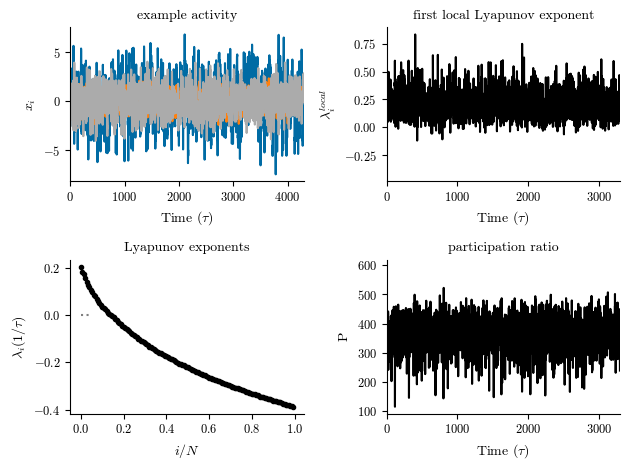

Elapsed time: 103.21265649795532 seconds


In [53]:
model = find_valid_model(tol=0.1, max_attempts=5, **base_kwargs)
time_start = time.time()
Lspectrum_np, LSall_np, pAll_np, = rate_Lyapunov_spectra_torch(N=model.N, g=model.g, W=model.W, dt=model.dt, tSim=model.T, nLE=150, tONS=1, seedIC=43, seedNet=42, seedONS=42, 
                                                               dns=False, plots=True, device=None, dtype=torch.float64, verbose=False, chunk_size=True)

time_end = time.time() - time_start
print(f"Elapsed time: {time_end} seconds")

gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

## Lyapunov Exponents - LOOP

In [54]:
# Helpers for file naming and saving
_DEC = 2 

def _tok(x, dec=_DEC):
    s = float(x) * (10 ** dec)
    n = int(s + 0.5) if s >= 0 else -int(-s + 0.5)
    w = dec + 1
    sign = '-' if n < 0 else ''
    return f"{sign}{abs(n):0{w}d}"

def tok_g(x):         return f"g{_tok(x)}"
def tok_s(x):         return f"s{_tok(x)}"
def tok_gamma(x):     return f"gamma{_tok(x)}"
def tok_dist(d):      return f"dist{d}"

def tag_NT(N, T):
    def _fmt_eng(x):
        import math
        if x == 0: return "0"
        e = int(math.floor(np.log10(abs(x)) / 3) * 3)
        m = x / (10**e)
        s = f"{m:g}e{e}"
        return s.replace('.', '_')
    return f"N{_fmt_eng(int(N))}_T{_fmt_eng(int(T))}"

def base_name_lyap(dist, g, s, gamma):
    return f"LLEs_{tok_dist(dist)}_{tok_g(g)}_{tok_s(s)}_{tok_gamma(gamma)}"

_RUN_RE = re.compile(r"^(?P<base>.+)_run(?P<idx>\d+)\.npz$")

def existing_run_indices(SAVE_DIR: str, base: str):
    patt = os.path.join(SAVE_DIR, base + "_run*.npz")
    idxs = []
    for f in glob.glob(patt):
        m = _RUN_RE.match(os.path.basename(f))
        if m:
            try: idxs.append(int(m.group("idx")))
            except ValueError: pass
    return sorted(idxs)

def missing_run_indices(SAVE_DIR: str, base: str, target_total: int):
    done = set(existing_run_indices(SAVE_DIR, base))
    return [i for i in range(1, target_total + 1) if i not in done]

def save_npz_with_run(SAVE_DIR: str, base: str, payload: dict, run_idx: int):
    os.makedirs(SAVE_DIR, exist_ok=True)
    stem = f"{base}_run{run_idx:02d}"
    path = os.path.join(SAVE_DIR, stem + ".npz")
    if os.path.exists(path):
        v = 2
        while True:
            alt = os.path.join(SAVE_DIR, f"{stem}_v{v}.npz")
            if not os.path.exists(alt):
                path = alt
                break
            v += 1
    tmp = path + ".tmp"
    with open(tmp, "wb") as f:
        np.savez_compressed(f, **payload)
    os.replace(tmp, path)
    return path

def save_json_sidecar(npz_path: str, meta: dict):
    stem, _ = os.path.splitext(npz_path)
    json_path = stem + ".json"
    meta = dict(meta)
    meta.setdefault("timestamp", time.strftime("%Y-%m-%d %H:%M:%S"))
    meta.setdefault("hostname", socket.gethostname())
    tmp = json_path + ".tmp"
    with open(tmp, "w", encoding="utf-8") as f:
        json.dump(meta, f, ensure_ascii=False, indent=2)
    os.replace(tmp, json_path)
    return json_path

## Worker

In [55]:
def run_once_lyap(dist, g, gamma, s, run_idx, base_kwargs, SAVE_ROOT, nLE=100, tONS=1.0, dns=False, device=None, dtype=torch.float64, verbose=1, seed_base=12345):
    '''
    Build model, compute LE, save results and metadata
    '''
    t0 = time.time()
    # seeds (different per run)
    np.random.seed(seed_base + 1000*run_idx + 11)
    torch.manual_seed(seed_base + 1000*run_idx + 17)

    # assemble cfg
    cfg = deepcopy(base_kwargs)
    cfg['distribution'] = dist
    cfg['g'] = g
    cfg['gamma'] = gamma
    cfg['s'] = s
    cfg['set_selfcoupling'] = bool(cfg.get('set_selfcoupling', False))

    # build model (respecting tol/max_attempts logic)
    model = find_valid_model(tol=0.1, max_attempts=20, **cfg)

    # compute LE
    dev = device or ('cuda' if torch.cuda.is_available() else 'cpu')
    Lspectrum, LSall, pAll = rate_Lyapunov_spectra_torch(
        N=model.N, g=model.g, W=model.W, dt=model.dt, tSim=model.T,
        nLE=nLE, tONS=tONS, seedIC=seed_base+run_idx*101+1,
        seedNet=seed_base+run_idx*101+2, seedONS=seed_base+run_idx*101+3,
        dns=dns, plots=False, device=dev, dtype=dtype, verbose=False, chunk_size=True
    )

    # dirs
    tag = tag_NT(model.N, model.T)
    dist_dir = os.path.join(SAVE_ROOT, f"{dist}_{tag}")
    os.makedirs(dist_dir, exist_ok=True)

    # filename base
    base = base_name_lyap(dist, model.g, model.s, model.gamma)

    # save npz
    payload = {
        "Lspectrum": np.asarray(Lspectrum),
        "LSall":     np.asarray(LSall),
        "pAll":      np.asarray(pAll),
    }
    npz_path = save_npz_with_run(dist_dir, base, payload, run_idx)

    # metadata
    meta = {
        "schema": "lle_meta/v1",
        "file": os.path.basename(npz_path),
        "run_idx": int(run_idx),
        "distribution": dist,
        "params": {"g": float(model.g), "gamma": float(model.gamma), "s": float(model.s)},
        "cfg": {
            "N": int(model.N), "T": float(model.T), "dt": float(model.dt),
            "tau_x": float(model.tau_x), "k_x": float(model.k_x),
            "activation": model.activation, "set_selfcoupling": bool(getattr(model, "set_selfcoupling", False)),
        },
        "nLE": int(nLE), "tONS": float(tONS), "dns": bool(dns),
        "device": str(dev), "dtype": str(dtype),
        "K_eff": float(model.K_eff), "K": float(model.K),
    }
    save_json_sidecar(npz_path, meta)

    # cleanup
    gc.collect()
    try:
        torch.cuda.empty_cache(); torch.cuda.synchronize()
    except Exception:
        pass
    return npz_path

## Jobs

In [56]:
def build_jobs(dist_list, g_list, gamma_list, s_list, N_RUNS, SAVE_ROOT, base_kwargs):
    '''
    Return list of (dist,g,gamma,s,run_idx) for missing runs
    '''
    tag = tag_NT(base_kwargs['N'], base_kwargs['T'])
    jobs = []
    for dist in dist_list:
        dist_dir = os.path.join(SAVE_ROOT, f"{dist}_{tag}")
        os.makedirs(dist_dir, exist_ok=True)
        for g in g_list:
            for gamma in gamma_list:
                for s in s_list:
                    base = base_name_lyap(dist, g, s, gamma)
                    print(base)
                    to_do = missing_run_indices(dist_dir, base, N_RUNS)
                    print(to_do)
                    for run_idx in to_do:
                        jobs.append((dist, g, gamma, s, run_idx))
    return jobs

## Driver

In [16]:
def run_all_jobs_sequential_lyap(jobs, base_kwargs, SAVE_ROOT, nLE=100, tONS=1.0,
                                 dns=False, device=None, dtype=torch.float64, verbose=True, percent_display=5):
    paths = []
    t0 = time.time()
    total = len(jobs)
    for k, (dist, g, gamma, s, run_idx) in enumerate(jobs, 1):
        path = run_once_lyap(dist, g, gamma, s, run_idx, base_kwargs, SAVE_ROOT,
                             nLE=nLE, tONS=tONS, dns=dns, device=device, dtype=dtype, verbose=verbose)
        paths.append(path)
        if verbose and (k % max(1, total//(100/percent_display)) == 0 or k == total):
            el = time.time()-t0
            m, sec = divmod(el, 60)
            print(f"[MAIN] {k}/{total} ({100.0*k/total:.1f}%), Time: {int(m)} min {sec:.1f} s")
    return paths


## Config

In [ ]:
# root folder
SAVE_ROOT = "/data/taffarello/hetrnn/LLEs"
os.makedirs(SAVE_ROOT, exist_ok=True)

# sweep
dist_list   = ['full', 'log_normal']
g_list      = [2.0]  # np.linspace(0.0, 3.0, 31)
gamma_list  = np.linspace(0, 1, 11)  # np.linspace(0.0, 3.0, 21)
s_list      = [0.0] # self-coupling (set to zero)
N_RUNS      = 5

# base config
base_kwargs = {
        'mu': 0,
        'g': None,
        'set_selfcoupling': True,
        's': None,
        'gamma': None,
        'N': 3000,
        'T': 3000,
        'dt': 0.05,
        'J': None,
        'A': None,
        'tau_x': 1.0,
        'k_x': 1.0,
        'tau_p': None,
        'p': None,
        'K': 100,
        'k_min': None,
        'k_max': None,
        'alpha': None,
        'mu_ln': 3,
        'sig_ln': 1,
        'activation': 'tanh',
        'distribution': None
    }

# build jobs
jobs = build_jobs(dist_list, g_list, gamma_list, s_list, N_RUNS, SAVE_ROOT, base_kwargs)
print(f"#jobs: {len(jobs)}")

In [ ]:
# Loop for simulationg with different N 
# root folder
SAVE_ROOT = "/data/taffarello/hetrnn/LLEs"
os.makedirs(SAVE_ROOT, exist_ok=True)

dist_list   = ['full', 'log_normal']
g_list      = [2.0]
gamma_list  = np.linspace(0, 1, 10)
s_list      = [0.0]
N_RUNS      = 5

N_list = [500, 1000, 2000, 4000, 8000] 

base_kwargs = {
    'mu': 0,
    'g': None,
    'set_selfcoupling': True,
    's': None,
    'gamma': None,
    'N': None,
    'T': 10000,
    'dt': 0.05,
    'J': None,
    'A': None,
    'tau_x': 1.0,
    'k_x': 1.0,
    'tau_p': None,
    'p': None,
    'K': 100,
    'k_min': None,
    'k_max': None,
    'alpha': None,
    'mu_ln': 3,
    'sig_ln': 1,
    'activation': 'tanh',
    'distribution': None
}

device = 'cuda' if torch.cuda.is_available() else 'cpu'

for N in N_list:
    base_kwargs_N = dict(base_kwargs)
    base_kwargs_N['N'] = N

    SAVE_ROOT_N = os.path.join(SAVE_ROOT, f"N{N}")
    os.makedirs(SAVE_ROOT_N, exist_ok=True)

    jobs = build_jobs(dist_list, g_list, gamma_list, s_list,
                      N_RUNS, SAVE_ROOT_N, base_kwargs_N)
    print(f"N={N} -> #jobs: {len(jobs)}")

    paths = run_all_jobs_sequential_lyap(
        jobs, base_kwargs_N, SAVE_ROOT_N,
        nLE=150, tONS=1.0, dns=False,
        device=device,
        dtype=torch.float64, verbose=True, percent_display=1
    )

## Run

In [ ]:
paths = run_all_jobs_sequential_lyap(
    jobs, base_kwargs, SAVE_ROOT,
    nLE=150, tONS=1.0, dns=False,
    device=('cuda' if torch.cuda.is_available() else 'cpu'),
    dtype=torch.float64, verbose=True, percent_display=1
)

# RESULTS

In [ ]:
# Helpers for loading and grouping results
_DEC = 2 
def _untok(tok, dec=_DEC):
    return int(tok) / (10 ** dec)

_RX_NPZ  = re.compile(r"^(?P<base>LLEs_.+?)_run(?P<idx>\d+)(?:_v\d+)?\.npz$")
_RX_JSON = re.compile(r"^(?P<base>LLEs_.+?)_run(?P<idx>\d+)(?:_v\d+)?\.json$")
_RX_BASE = re.compile(r"^LLEs_dist(?P<dist>[\w-]+)_g(?P<g>-?\d+)_s(?P<s>-?\d+)_gamma(?P<gamma>-?\d+)$")

def _group_by_base(load_dir, ext=".npz", rx=_RX_NPZ):
    all_files = glob.glob(os.path.join(load_dir, f"*{ext}"))
    matches = [(f, rx.search(os.path.basename(f))) for f in all_files]
    matches = [(f, m) for f, m in matches if m]
    groups = {}
    for f, m in matches:
        base = m.group("base")
        idx  = int(m.group("idx"))
        groups.setdefault(base, []).append((idx, f))
    for base in groups:
        groups[base].sort(key=lambda t: t[0])
    return groups

def load_npz_runs(load_dir, verbose=True):
    groups = _group_by_base(load_dir, ext=".npz", rx=_RX_NPZ)
    data = {}
    for base, items in sorted(groups.items()):
        runs = []
        for idx, f in items:
            with np.load(f, allow_pickle=False) as npz:
                payload = {k: npz[k] for k in npz.files}  # Lspectrum, LSall, pAll
            runs.append({"run_idx": idx, "file": f, **payload})
        data[base] = runs
        if verbose and runs:
            shapes = {k: runs[0][k].shape for k in runs[0] if k in ("Lspectrum","LSall","pAll")}
            print(f"{base}: {len(runs)} runs, shapes {shapes}")
    return data

def load_json_sidecars(load_dir, verbose=True):
    groups = _group_by_base(load_dir, ext=".json", rx=_RX_JSON)
    metas = {}
    for base, items in sorted(groups.items()):
        lst = []
        for idx, f in items:
            try:
                with open(f, "r", encoding="utf-8") as fh:
                    meta = json.load(fh)
            except Exception:
                meta = {}
            meta["_run_idx"] = idx
            meta["_file"] = f
            lst.append(meta)
        metas[base] = lst
    return metas

def parse_base_params(base):
    m = _RX_BASE.match(base)
    if not m:
        return None
    return {
        "dist":  m.group("dist"),
        "g":     _untok(m.group("g")),
        "s":     _untok(m.group("s")),
        "gamma": _untok(m.group("gamma")),
    }

def select_bases_by_params(bases, dist=None, g_list=None, s_list=None, gamma_list=None):
    out = []
    for b in bases:
        p = parse_base_params(b)
        if p is None: 
            continue
        if dist is not None and p["dist"] != dist: 
            continue
        if g_list is not None and p["g"] not in g_list: 
            continue
        if s_list is not None and p["s"] not in s_list: 
            continue
        if gamma_list is not None and p["gamma"] not in gamma_list: 
            continue
        out.append(b)
    return out

def load_lle_folder(dist_dir, verbose=True):
    runs  = load_npz_runs(dist_dir, verbose=verbose)
    metas = load_json_sidecars(dist_dir, verbose=verbose)
    return runs, metas

In [ ]:
ROOT = "/data/taffarello/hetrnn/LLEs"
tag  = tag_NT(3000, 3000) # N=3000, T=3000

dist = "full"
dist_dir = os.path.join(ROOT, f"{dist}_{tag}")

runs, metas = load_lle_folder(dist_dir, verbose=False)
bases = list(runs.keys())

g_list     = [0.0, 0.6, 1.2, 1.8, 2.4, 3.0]
gamma_list = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

sel = select_bases_by_params(
    bases,
    dist=dist,
    g_list=g_list,
    s_list=[0.0],
    gamma_list=gamma_list,
)
print("selected bases:", sel)

selected bases: ['LLEs_distfull_g000_s000_gamma000', 'LLEs_distfull_g000_s000_gamma020', 'LLEs_distfull_g000_s000_gamma040', 'LLEs_distfull_g000_s000_gamma060', 'LLEs_distfull_g000_s000_gamma080', 'LLEs_distfull_g000_s000_gamma100', 'LLEs_distfull_g060_s000_gamma000', 'LLEs_distfull_g060_s000_gamma020', 'LLEs_distfull_g060_s000_gamma040', 'LLEs_distfull_g060_s000_gamma060', 'LLEs_distfull_g060_s000_gamma080', 'LLEs_distfull_g060_s000_gamma100', 'LLEs_distfull_g120_s000_gamma000', 'LLEs_distfull_g120_s000_gamma020', 'LLEs_distfull_g120_s000_gamma040', 'LLEs_distfull_g120_s000_gamma060', 'LLEs_distfull_g120_s000_gamma080', 'LLEs_distfull_g120_s000_gamma100', 'LLEs_distfull_g180_s000_gamma000', 'LLEs_distfull_g180_s000_gamma020', 'LLEs_distfull_g180_s000_gamma040', 'LLEs_distfull_g180_s000_gamma060', 'LLEs_distfull_g180_s000_gamma080', 'LLEs_distfull_g180_s000_gamma100', 'LLEs_distfull_g240_s000_gamma000', 'LLEs_distfull_g240_s000_gamma020', 'LLEs_distfull_g240_s000_gamma040', 'LLEs_distf

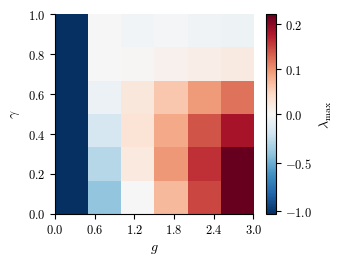

In [122]:
_RX_BASE = re.compile(r"^LLEs_dist(?P<dist>[^_]+)_g(?P<g>-?\d+)_s(?P<s>-?\d+)_gamma(?P<gamma>-?\d+)$")

means = {}         
counts = {}        
s_seen = set()

for b in sel:
    m = _RX_BASE.match(b)
    if not m or b not in runs:
        continue
    g  = _untok(m.group("g"))
    s  = _untok(m.group("s"))
    ga = _untok(m.group("gamma"))
    s_seen.add(s)

    # max LE per run
    vals = []
    for r in runs[b]:
        lam = np.asarray(r["Lspectrum"])
        if lam.size == 0:
            continue
        vals.append(float(lam[0]))
    if len(vals) == 0:
        continue

    key = (g, ga)
    if key not in means:
        means[key] = []
        counts[key] = 0
    means[key].extend(vals)
    counts[key] += len(vals)

# average over runs
for key in list(means.keys()):
    arr = np.array(means[key], float)
    means[key] = float(arr.mean())

# build coarse grid Z with shape (len(gammas), len(gs))
gs = sorted({k[0] for k in means.keys()})
gammas = sorted({k[1] for k in means.keys()})
Z = np.full((len(gammas), len(gs)), np.nan, dtype=float)
for j, g in enumerate(gs):
    for i, ga in enumerate(gammas):
        if (g, ga) in means:
            Z[i, j] = means[(g, ga)]

# choose symmetric range or let TwoSlopeNorm handle asymmetry
vmax = np.nanmax(Z)
vmin = np.nanmin(Z)
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)

# imshow with visual smoothing
Zplot = np.ma.array(Z, mask=np.isnan(Z))
plt.figure(figsize=(9/2.54, 7/2.54))
im = plt.imshow(Zplot, origin="lower", extent=(min(gs), max(gs), min(gammas), max(gammas)),
                aspect="auto", norm=norm, cmap="RdBu_r", interpolation=None)  
cmap = im.get_cmap().with_extremes(bad="lightgray")
im.set_cmap(cmap)
cbar = plt.colorbar(im)
cbar.set_ticks([-1.0, -0.5, 0.0, 0.1, 0.2])
cbar.set_label(r"$\lambda_{\max}$")
plt.xlabel(r"$g$")
plt.ylabel(r"$\gamma$")
plt.xticks(gs)
plt.yticks(gammas)
plt.savefig(f'/home/taffarello/codes/rnn/figures/LLEs/LLE_g_vs_gam_full.png', bbox_inches="tight", dpi=300)
plt.show()


## Lognormal

In [ ]:
ROOT = "/data/taffarello/hetrnn/LLEs"
tag  = tag_NT(3000, 3000)

_RX_BASE = re.compile(r"^LLEs_dist(?P<dist>[\w-]+)_g(?P<g>-?\d+)_s(?P<s>-?\d+)_gamma(?P<gamma>-?\d+)$")

dist = "log_normal"  
dist_dir = os.path.join(ROOT, f"{dist}_{tag}")

runs, metas = load_lle_folder(dist_dir, verbose=False)
bases = list(runs.keys())

g_list     = [round(float(v), _DEC) for v in np.linspace(0, 3, 31)]
gamma_list = [round(float(v), _DEC) for v in np.linspace(0, 1, 21)]

sel = select_bases_by_params(
    bases,
    dist=dist,
    g_list=g_list,
    s_list=[0.0],
    gamma_list=gamma_list,
)
print("selected bases:", sel)

selected bases: ['LLEs_distlog_normal_g000_s000_gamma000', 'LLEs_distlog_normal_g000_s000_gamma005', 'LLEs_distlog_normal_g000_s000_gamma010', 'LLEs_distlog_normal_g000_s000_gamma015', 'LLEs_distlog_normal_g000_s000_gamma020', 'LLEs_distlog_normal_g000_s000_gamma025', 'LLEs_distlog_normal_g000_s000_gamma030', 'LLEs_distlog_normal_g000_s000_gamma035', 'LLEs_distlog_normal_g000_s000_gamma040', 'LLEs_distlog_normal_g000_s000_gamma045', 'LLEs_distlog_normal_g000_s000_gamma050', 'LLEs_distlog_normal_g000_s000_gamma055', 'LLEs_distlog_normal_g000_s000_gamma060', 'LLEs_distlog_normal_g000_s000_gamma065', 'LLEs_distlog_normal_g000_s000_gamma070', 'LLEs_distlog_normal_g000_s000_gamma075', 'LLEs_distlog_normal_g000_s000_gamma080', 'LLEs_distlog_normal_g000_s000_gamma085', 'LLEs_distlog_normal_g000_s000_gamma090', 'LLEs_distlog_normal_g000_s000_gamma095', 'LLEs_distlog_normal_g000_s000_gamma100', 'LLEs_distlog_normal_g010_s000_gamma000', 'LLEs_distlog_normal_g010_s000_gamma005', 'LLEs_distlog_nor

In [185]:
# helpers for plotting
def estract_g(b):
    m = _RX_BASE.match(b)
    if not m:
        return None
    return float(_untok(m.group("g")))

def build_points(sel_bases):
    pts = []
    for b in sel_bases:
        g = estract_g(b)
        if g is None:
            continue
        vals = [float(r["Lspectrum"][0]) for r in runs[b] if "Lspectrum" in r and len(r["Lspectrum"]) > 0]
        if not vals:
            continue
        mean = float(np.mean(vals))
        se   = float(np.std(vals, ddof=1) / np.sqrt(len(vals))) if len(vals) > 1 else 0.0
        pts.append((g, mean, se))
    pts.sort(key=lambda t: t[0])
    if not pts:
        return [], [], []
    gs    = [p[0] for p in pts]
    means = [p[1] for p in pts]
    ses   = [p[2] for p in pts]
    return gs, means, ses

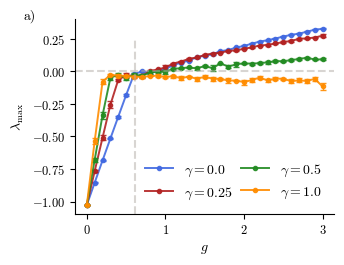

In [186]:
gamma_list_lle = [0.0, 0.25, 0.5, 1.0] 
gamma_colors = ['royalblue', 'firebrick', 'forestgreen', 'darkorange']

plt.figure(figsize=(9/2.54, 7/2.54))
for i, gamma in enumerate(gamma_list_lle):
    sel = select_bases_by_params(
        bases,
        dist=dist,
        g_list=g_list,
        s_list=[0.0],
        gamma_list=[gamma],
    )
    gs, means, ses = build_points(sel)
    if not gs:
        print(f"No data for gamma={gamma}")
        continue

    color = gamma_colors[i]
    (line,) = plt.plot(gs, means, 'o-', ms=3, lw=1.4, label=rf'$\gamma={gamma}$', color=color if color else None, alpha=0.9)

    if any(s > 0 for s in ses):  # type: ignore
        plt.errorbar(gs, means, yerr=ses, fmt='none', elinewidth=1, capsize=2, alpha=0.9,
                        color=line.get_color() if hasattr(line, "get_color") else color)

# zero-line
try:
    zero_color = my_palettes['5'][2]
except Exception:
    zero_color = None
plt.axhline(0, ls='--', alpha=0.5, color=zero_color if zero_color else None)

plt.xlabel(r'$g$')
plt.axvline(0.61, ymin=0, ymax=0.9, ls='--', lw=1.5,alpha=0.5, color=zero_color if zero_color else None)
plt.ylabel(r'$\lambda_{\max}$')
plt.legend(frameon=False, ncol=2, columnspacing=0.6)
plt.text(-0.20, 1.00, 'a)', transform=plt.gca().transAxes)
plt.savefig(f'/home/taffarello/codes/rnn/figures/LLEs/LLEs_log_normal.png', bbox_inches="tight", dpi=400)
plt.show()

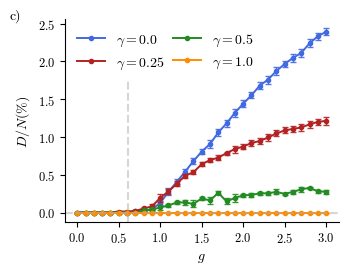

In [187]:
gamma_list = [0.0, 0.25, 0.5, 1.0]

plt.figure(figsize=(9/2.54, 7/2.54))

for i, gamma in enumerate(gamma_list):
    sel = select_bases_by_params(
        bases,
        dist=dist,
        g_list=g_list,
        s_list=[0.0],
        gamma_list=[gamma],
    )
    if not sel:
        print(f"No data for gamma={gamma}")
        continue

    pts = []
    for b in sel:
        m = _RX_BASE.match(b)
        if not m or b not in runs:
            continue
        g  = float(_untok(m.group("g")))
        Ds = []
        for r in runs[b]:
            lam = np.asarray(r["Lspectrum"], float)
            D = int(np.sum(np.cumsum(lam) > 0))
            Ds.append(D/30)
        if len(Ds) == 0:
            continue
        mean = float(np.mean(Ds))
        se   = float(np.std(Ds, ddof=1)/np.sqrt(len(Ds))) if len(Ds) > 1 else 0.0
        pts.append((g, mean, se))

    pts.sort(key=lambda t: t[0])
    gs    = [p[0] for p in pts]
    means = [p[1] for p in pts]
    ses   = [p[2] for p in pts]
    if not gs:
        print(f"No data (after parsing) for gamma={gamma}")
        continue

    color = gamma_colors[i]

    (line,) = plt.plot(gs, means, 'o-', ms=3, lw=1.4, label=rf'$\gamma={gamma}$',
                       color=color if color else None)

    if any(s > 0 for s in ses):  # type: ignore
        plt.errorbar(gs, means, yerr=ses, fmt='none', elinewidth=1, capsize=2, alpha=0.9,
                     color=line.get_color() if hasattr(line, "get_color") else color)

zero_color = None
try:
    zero_color = my_palettes['5'][2]
except Exception:
    pass
plt.axhline(0, ls='--', alpha=0.5, color=zero_color if zero_color else None)
plt.axvline(0.61, ymin=0.0, ymax=0.7, ls='--', lw=1.5,alpha=0.5, color=zero_color if zero_color else None)
plt.xlabel(r'$g$')
plt.ylabel(r'$D/N$(%)')
plt.legend(frameon=False, ncol=2, columnspacing=0.6)
plt.tight_layout()
plt.text(-0.20, 1.00, 'c)', transform=plt.gca().transAxes)
plt.savefig(f'/home/taffarello/codes/rnn/figures/LLEs/Dimensionality_log_normal.png', bbox_inches="tight", dpi=400)
plt.show()

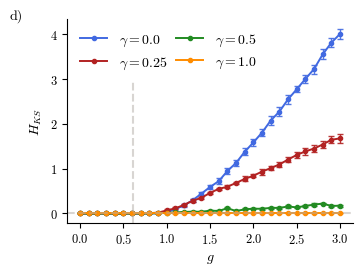

In [188]:
gamma_list = [0.0, 0.25, 0.5, 1.0]

plt.figure(figsize=(9/2.54, 7/2.54))

for i, gamma in enumerate(gamma_list):
    sel = select_bases_by_params(
        bases,
        dist=dist,
        g_list=g_list,
        s_list=[0.0],
        gamma_list=[gamma],
    )
    if not sel:
        print(f"No data for gamma={gamma}")
        continue

    pts = []
    for b in sel:
        m = _RX_BASE.match(b)
        if not m or b not in runs:
            continue
        g  = float(_untok(m.group("g")))
        Hs = []
        for r in runs[b]:
            lam = np.asarray(r["Lspectrum"], float)
            H = float(np.sum(lam[lam > 0.0]))
            Hs.append(H)
        if len(Hs) == 0:
            continue
        mean = float(np.mean(Hs))
        se   = float(np.std(Hs, ddof=1)/np.sqrt(len(Hs))) if len(Hs) > 1 else 0.0
        pts.append((g, mean, se))

    pts.sort(key=lambda t: t[0])
    gs    = [p[0] for p in pts]
    means = [p[1] for p in pts]
    ses   = [p[2] for p in pts]
    if not gs:
        print(f"No data (after parsing) for gamma={gamma}")
        continue

    color = gamma_colors[i]

    (line,) = plt.plot(gs, means, 'o-', ms=3, lw=1.4, label=rf'$\gamma={gamma}$',
                       color=color if color else None)

    if any(s > 0 for s in ses):  # type: ignore
        plt.errorbar(gs, means, yerr=ses, fmt='none', elinewidth=1, capsize=2, alpha=0.9,
                     color=line.get_color() if hasattr(line, "get_color") else color)

zero_color = None
try:
    zero_color = my_palettes['5'][2]
except Exception:
    pass

plt.axhline(0, ls='--', alpha=0.5, color=zero_color if zero_color else None)
plt.axvline(0.61, ymin=0.0, ymax=0.7, ls='--', lw=1.5, alpha=0.5, color=zero_color if zero_color else None)

plt.xlabel(r'$g$')
plt.ylabel(r'$H_{KS}$')
plt.legend(frameon=False, ncol=2, columnspacing=0.6)
plt.tight_layout()
plt.text(-0.20, 1.00, 'd)', transform=plt.gca().transAxes)
plt.savefig('/home/taffarello/codes/rnn/figures/LLEs/Entropy_log_normal.png', bbox_inches="tight", dpi=400)
plt.show()

## Lognormal vs full

In [166]:
# Root folder
ROOT = "/data/taffarello/hetrnn/LLEs/"

# Ns and dists to load
N_LIST = [1000, 2000, 4000, 8000]
DIST_LIST = ["full", "log_normal"]

# Selection parameters
g_list     = [2.0]
s_list     = [0.0]
gamma_list = [round(float(v), _DEC) for v in np.linspace(0, 1, 10)]

def extract_gamma_curve_from_runs(runs, sel_bases):
    pts = []
    for b in sel_bases:
        m = _RX_BASE.match(b)
        if not m:
            continue

        gamma = float(_untok(m.group("gamma")))

        vals = [
            float(r["Lspectrum"][0])
            for r in runs.get(b, [])
            if "Lspectrum" in r and len(r["Lspectrum"]) > 0
        ]
        if len(vals) == 0:
            continue

        mean = float(np.mean(vals))
        se   = float(np.std(vals, ddof=1) / np.sqrt(len(vals))) if len(vals) > 1 else 0.0
        pts.append((gamma, mean, se))

    pts.sort(key=lambda t: t[0])
    gammas = [p[0] for p in pts]
    means  = [p[1] for p in pts]
    ses    = [p[2] for p in pts]
    return gammas, means, ses

def _np(x):
    return np.asarray(x, dtype=float)

# Load curves
full_data = {}
log_data  = {}

for N in N_LIST:
    tag = tag_NT(N, 10000)

    for dist in DIST_LIST:
        dist_dir = os.path.join(ROOT, f"N{N}", f"{dist}_{tag}")
        print("Loading from:", dist_dir)

        runs, metas = load_lle_folder(dist_dir, verbose=False)
        bases = list(runs.keys())

        sel = select_bases_by_params(
            bases,
            dist=dist,
            g_list=g_list,
            s_list=s_list,
            gamma_list=gamma_list,
        )

        gammas, means, ses = extract_gamma_curve_from_runs(runs, sel)

        if dist == "full":
            full_data[N] = (gammas, means, ses)
        elif dist == "log_normal":
            log_data[N] = (gammas, means, ses)


Loading from: /data/taffarello/hetrnn/LLEs/N1000/full_N1e3_T10e3
Loading from: /data/taffarello/hetrnn/LLEs/N1000/log_normal_N1e3_T10e3
Loading from: /data/taffarello/hetrnn/LLEs/N2000/full_N2e3_T10e3
Loading from: /data/taffarello/hetrnn/LLEs/N2000/log_normal_N2e3_T10e3
Loading from: /data/taffarello/hetrnn/LLEs/N4000/full_N4e3_T10e3
Loading from: /data/taffarello/hetrnn/LLEs/N4000/log_normal_N4e3_T10e3
Loading from: /data/taffarello/hetrnn/LLEs/N8000/full_N8e3_T10e3
Loading from: /data/taffarello/hetrnn/LLEs/N8000/log_normal_N8e3_T10e3


/tmp/ipykernel_123456/2372011295.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig("/home/taffarello/codes/rnn/figures/LLEs/supp_LLE_scaling.png", dpi=400, bbox_inches="tight")


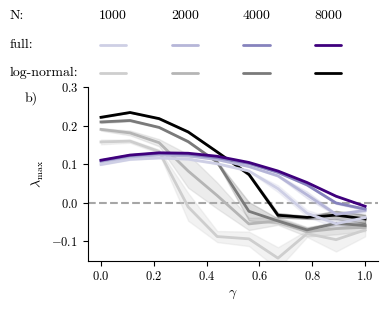

In [ ]:
Ns = sorted(set(full_data.keys()) | set(log_data.keys()))

# Normalize N for color gradients
norm = mcolors.Normalize(vmin=min(Ns), vmax=max(Ns))

# Sequential matplotlib colormaps
cmap_full = plt.get_cmap("Purples")
cmap_log  = plt.get_cmap("Greys")

def color_from_cmap(cmap, N, lo=0.3, hi=1):
    t = norm(N)
    t = lo + (hi - lo) * t
    return cmap(t)

# Figure axes
fig = plt.figure(figsize=(9/2.54, 8/2.54))
ax = fig.add_axes([0.14, 0.14, 0.82, 0.55])
ax_leg = fig.add_axes([0.14, 0.73, 0.75, 0.10])
ax_leg.set_axis_off()

lw = 2
band_alpha = 0.25

# Plot log-normal
for N in sorted(log_data):
    g, m, se = map(_np, log_data[N])
    col = color_from_cmap(cmap_log, N)
    ax.plot(g, m, "-", lw=lw, color=col)
    ax.fill_between(g, m - se, m + se, color=col, alpha=band_alpha)

# Plot full
for N in sorted(full_data):
    g, m, se = map(_np, full_data[N])
    col = color_from_cmap(cmap_full, N)
    ax.plot(g, m, "-", lw=lw, color=col)
    ax.fill_between(g, m - se, m + se, color=col, alpha=band_alpha)

# Axes formatting
ax.axhline(0, ls="--", color="grey", lw=1.5, alpha=0.7, zorder=-1)
ax.set_xlabel(r"$\gamma$")
ax.set_ylabel(r"$\lambda_{\max}$")
ax.set_ylim(-0.15, 0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(top=False, right=False)

# Table-like legend
x_label = -0.1
x0 = 0.25
x1 = 0.98
xs = np.linspace(x0, x1, len(Ns))

y_header = 0.75
y_full   = 0.5
y_log    = 0.25

for x, N in zip(xs, Ns):
    ax_leg.text(x, y_header, f"{N}", ha="center", va="center", fontsize=10)

ax_leg.text(x_label, y_header, "N:", ha="left", va="center", fontsize=10)
ax_leg.text(x_label, y_full, "full:", ha="left", va="center", fontsize=10)
ax_leg.text(x_label, y_log, "log-normal:", ha="left", va="center", fontsize=10)

seg_half = 0.045
for x, N in zip(xs, Ns):
    col_f = color_from_cmap(cmap_full, N)
    ax_leg.plot([x - seg_half, x + seg_half], [y_full, y_full], lw=lw, color=col_f, solid_capstyle="round")

    col_l = color_from_cmap(cmap_log, N)
    ax_leg.plot([x - seg_half, x + seg_half], [y_log, y_log], lw=lw, color=col_l, solid_capstyle="round")

plt.text(-0.05, 0.0, 'b)')
plt.savefig("/home/taffarello/codes/rnn/figures/LLEs/supp_LLE_scaling.png", dpi=400, bbox_inches="tight")
plt.show()

## Lyapunov Panel

In [216]:
# helpers

# Load simulation data from .npz file
def load_sim(path):
    d = np.load(path)
    return dict(
        x = d["x"],
        degree = d["degree"],
        dt = float(d["dt"]),
        g = float(d["g"]), s = float(d["s"]), gamma = float(d["gamma"]),
        mu_ln = float(d["mu_ln"]), sig_ln = float(d["sig_ln"]),
        N = int(d["N"]), T = int(d["T"])
    )

# Create degree bin edges
def make_degree_bins(degree_vect, n_bins=4, method="log-quantile"):
    degree_vect = np.asarray(degree_vect[degree_vect > 0], float)
    if method == "log-quantile":
        z = np.log(degree_vect)
        qs = np.linspace(0, 1, n_bins + 1)
        edges = np.exp(np.quantile(z, qs))
        edges[0] = degree_vect.min()
        edges[-1] = degree_vect.max()
    elif method == "logspace":
        kmin = degree_vect.min()
        kmax = degree_vect.max()
        edges = np.logspace(np.log10(kmin), np.log10(kmax), n_bins + 1)
    else:
        raise ValueError("method should be 'log-quantile' o 'logspace'")
    return edges

# Sample activity values grouped by degree bins
def sample_x_by_degree_bins(x, degree_vect, edges, burn_in_frac=0.20, stride=100, max_neurons_per_bin=None, random_state=None):
    x = np.asarray(x)
    degree_vect = np.asarray(degree_vect, float)
    N, T = x.shape
    if degree_vect.shape[0] != N:
        raise ValueError("degree_vect length != N")
    t0 = int(np.floor(T * float(burn_in_frac)))
    if t0 >= T: 
        raise ValueError("burn_in_frac troppo grande")
    if stride < 1:
        raise ValueError("stride deve essere >= 1")

    rng = np.random.default_rng(random_state)
    samples_list = []
    bin_labels = []
    bin_indices = []

    # Loop over bins
    for bi in range(len(edges) - 1):
        kmin, kmax = edges[bi], edges[bi+1]

        # Select neurons in bin
        if bi < len(edges) - 2:
            idx = np.where((degree_vect >= kmin) & (degree_vect < kmax))[0]
        else:
            idx = np.where((degree_vect >= kmin) & (degree_vect <= kmax))[0]

        if idx.size == 0:
            samples_list.append(np.array([], dtype=float))
            bin_labels.append((kmin, kmax))
            bin_indices.append(idx)
            continue

        # Optional subsampling of neurons
        if max_neurons_per_bin is not None and idx.size > max_neurons_per_bin:
            idx = rng.choice(idx, size=int(max_neurons_per_bin), replace=False)

        # Extract activity after burn-in and with stride
        Xb = x[idx, t0::stride]

        samples_list.append(Xb.ravel())
        bin_labels.append((kmin, kmax))
        bin_indices.append(idx)

    return samples_list, bin_labels, bin_indices

# Build trajectory-based stationary distribution
def build_trajstatdist(x, degree_vect, n_bins=4, burn_in_frac=0.20, dt=0.05, random_state=0, t_samples=50.0):
    edges = make_degree_bins(degree_vect, n_bins=n_bins, method="log-quantile")
    samples_list, bin_labels, _ = sample_x_by_degree_bins(
        x, degree_vect, edges,
        burn_in_frac=burn_in_frac,
        stride=int(round(t_samples/dt)),
        max_neurons_per_bin=None,
        random_state=random_state
    )
    return dict(x=x, degree=degree_vect, edges=edges, samples=samples_list, labels=bin_labels)

# Plot LLE

# Build grid of mean LLE values over (g, gamma)
def build_LLE_grid(sel, runs, _RX_BASE, _untok):
    means, counts = {}, {}
    s_seen = set()

    # Loop over selected base names
    for b in sel:
        m = _RX_BASE.match(b)
        if not m or b not in runs:
            continue

        # Extract parameters from name
        g  = _untok(m.group("g"))
        s  = _untok(m.group("s"))
        ga = _untok(m.group("gamma"))
        s_seen.add(s)

        # Collect first Lyapunov exponent across runs
        vals = []
        for r in runs[b]:
            lam = np.asarray(r["Lspectrum"])
            if lam.size == 0:
                continue
            vals.append(float(lam[0]))

        if len(vals) == 0:
            continue

        key = (g, ga)
        if key not in means:
            means[key] = []
            counts[key] = 0

        means[key].extend(vals)
        counts[key] += len(vals)

    # Compute mean for each (g, gamma)
    for key in list(means.keys()):
        arr = np.array(means[key], float)
        means[key] = float(arr.mean())

    # Unique sorted parameter values
    gs = sorted({k[0] for k in means.keys()})
    gammas = sorted({k[1] for k in means.keys()})

    # Fill 2D grid
    Z = np.full((len(gammas), len(gs)), np.nan, dtype=float)
    for j, g in enumerate(gs):
        for i, ga in enumerate(gammas):
            if (g, ga) in means:
                Z[i, j] = means[(g, ga)]

    return np.array(gs), np.array(gammas), Z


# Plot LLE heatmap
def plot_LLE(ax, gs_vals, gammas_vals, Z, linthresh=0.01, linscale=1.0):
    z_abs = np.nanmax(np.abs(Z))
    vmin = -z_abs
    vmax =  z_abs

    # Symmetric log normalization
    norm = SymLogNorm(
        linthresh=linthresh,
        linscale=linscale,
        vmin=vmin,
        vmax=vmax
    )
    Zplot = np.ma.array(Z, mask=np.isnan(Z))

    # Heatmap
    im = ax.imshow(
        Zplot,
        origin="lower",
        extent=(gs_vals.min(), gs_vals.max(),
                gammas_vals.min(), gammas_vals.max()),
        aspect="auto",
        norm=norm,
        cmap="RdBu_r",
        interpolation="bilinear"
    )

    # Theoretically obtained critical line  
    data = np.load("/home/zenari/g_crit_theory.npz")
    g_list_theory = data["g_list_theory"]
    gamma_list_theory = data["gamma_list_theory"]

    # Plot theoretical critical line
    ax.plot(g_list_theory, gamma_list_theory, ls='-', lw=2, color='black')

    # Set color for missing values
    im.set_cmap(im.get_cmap().with_extremes(bad="lightgray"))

    return im


# Plot dynamics and PDFs by degree bin
def plot_dyn_pdf(ax_dyn, ax_pdf, x, t, samples_list, bin_labels, degree_vect, edges, colors, rng_seed=3, max_traj_per_bin=4, xmin=0, xmax=2000, ymin=10, ymax=10):
    dt = t[1] - t[0]
    xmin = int(xmin * dt)
    xmax = int(xmax * dt)

    rng = np.random.default_rng(rng_seed)
    bin_id = np.digitize(degree_vect, edges) - 1

    # Loop over bins
    for b, (kmin, kmax) in enumerate(bin_labels):
        color = colors[b % len(colors)]
        idx = np.where(bin_id == b)[0]
        if len(idx) == 0:
            continue

        # Randomly select trajectories
        pick = rng.choice(idx, size=min(max_traj_per_bin, len(idx)), replace=False)
        for n in pick:
            ax_dyn.plot(t[:], x[n, :].T, lw=1.5, alpha=0.75, color=color)

        # Plot stationary distribution
        ax_pdf.hist(
            samples_list[b], bins=50 + 20*b, density=True,
            histtype='step', orientation='horizontal',
            color=color, label=f"[{kmin:.1f}, {kmax:.1f}]",
            lw=1.5, alpha=0.75
        )

    # Axes formatting
    ax_dyn.set_xlabel(r"$t$")
    ax_dyn.set_ylabel(r"$x(t)$")
    ax_dyn.set_ylim(ymin, ymax)
    ax_dyn.set_xlim(xmin, xmax)

    ax_pdf.set_xlabel(r"$p(x^*)$")
    ax_pdf.yaxis.set_ticklabels([])
    ax_pdf.set_xlim(left=0, right=None)
    ax_pdf.set_yticks([])
    ax_pdf.set_xticks([])

    ax_dyn.set_yticks([])
    ax_dyn.set_xticks([])

In [193]:
# paths to saved simulations of heterogeneous RNNs (lognormal degree distribution, mu=3, sigma=1)
path_a = "/home/taffarello/codes/rnn/fast_data/sim_a_data.npz"
path_d = "/home/taffarello/codes/rnn/fast_data/sim_b_data.npz"
path_c = "/home/taffarello/codes/rnn/fast_data/sim_c_data.npz"
path_b = "/home/taffarello/codes/rnn/fast_data/sim_d_data.npz"

# Prepare data simulations
sim_a = load_sim(path_a); panelA = build_trajstatdist(sim_a["x"], sim_a["degree"], dt=sim_a["dt"], t_samples=50); panelA["dt"]=sim_a["dt"]; panelA["tag"]="a"
sim_b = load_sim(path_b); panelB = build_trajstatdist(sim_b["x"], sim_b["degree"], dt=sim_b["dt"], t_samples=50); panelB["dt"]=sim_b["dt"]; panelB["tag"]="b"
sim_c = load_sim(path_c); panelC = build_trajstatdist(sim_c["x"], sim_c["degree"], dt=sim_c["dt"], t_samples=50); panelC["dt"]=sim_c["dt"]; panelC["tag"]="c"
sim_d = load_sim(path_d); panelD = build_trajstatdist(sim_d["x"], sim_d["degree"], dt=sim_d["dt"], t_samples=50); panelD["dt"]=sim_d["dt"]; panelD["tag"]="d"

In [ ]:
# Prepare data for LLE grid
ROOT = "/data/taffarello/hetrnn/LLEs"
tag  = tag_NT(3000, 3000)

_RX_BASE = re.compile(r"^LLEs_dist(?P<dist>[\w-]+)_g(?P<g>-?\d+)_s(?P<s>-?\d+)_gamma(?P<gamma>-?\d+)$")

dist = "log_normal"  
dist_dir = os.path.join(ROOT, f"{dist}_{tag}")

runs, metas = load_lle_folder(dist_dir, verbose=False)
bases = list(runs.keys())

g_list     = [round(float(v), _DEC) for v in np.linspace(0, 3, 31)]
gamma_list = [round(float(v), _DEC) for v in np.linspace(0, 1, 21)]

sel = select_bases_by_params(
    bases,
    dist=dist,
    g_list=g_list,
    s_list=[0.0],
    gamma_list=gamma_list,
)
print("selected bases:", sel)

selected bases: ['LLEs_distlog_normal_g000_s000_gamma000', 'LLEs_distlog_normal_g000_s000_gamma005', 'LLEs_distlog_normal_g000_s000_gamma010', 'LLEs_distlog_normal_g000_s000_gamma015', 'LLEs_distlog_normal_g000_s000_gamma020', 'LLEs_distlog_normal_g000_s000_gamma025', 'LLEs_distlog_normal_g000_s000_gamma030', 'LLEs_distlog_normal_g000_s000_gamma035', 'LLEs_distlog_normal_g000_s000_gamma040', 'LLEs_distlog_normal_g000_s000_gamma045', 'LLEs_distlog_normal_g000_s000_gamma050', 'LLEs_distlog_normal_g000_s000_gamma055', 'LLEs_distlog_normal_g000_s000_gamma060', 'LLEs_distlog_normal_g000_s000_gamma065', 'LLEs_distlog_normal_g000_s000_gamma070', 'LLEs_distlog_normal_g000_s000_gamma075', 'LLEs_distlog_normal_g000_s000_gamma080', 'LLEs_distlog_normal_g000_s000_gamma085', 'LLEs_distlog_normal_g000_s000_gamma090', 'LLEs_distlog_normal_g000_s000_gamma095', 'LLEs_distlog_normal_g000_s000_gamma100', 'LLEs_distlog_normal_g010_s000_gamma000', 'LLEs_distlog_normal_g010_s000_gamma005', 'LLEs_distlog_nor

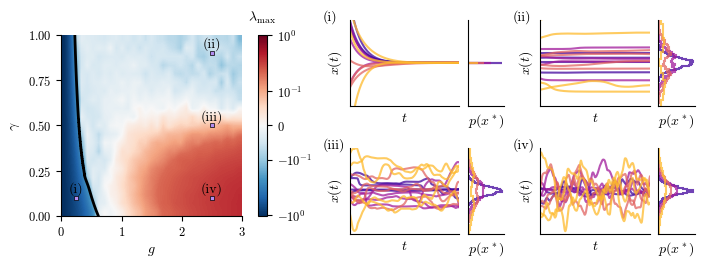

In [239]:
# main figure
# Connstruct grid
fig = plt.figure(figsize=(18/2.54, 6.5/2.54), constrained_layout=True)
outer = fig.add_gridspec(nrows=2, ncols=3, width_ratios=[1.3, 1, 1],
                         hspace=0.05, wspace=0.05)

# Left panel for LLE heatmap
ax_left = fig.add_subplot(outer[:, 0])
gs_vals, gammas_vals, Z = build_LLE_grid(sel, runs, _RX_BASE, _untok)

# use the new SymLogNorm-based plot_LLE
im = plot_LLE(ax_left, gs_vals, gammas_vals, Z, linthresh=0.15, linscale=1.0)
cbar = fig.colorbar(im, ax=ax_left, fraction=0.045, pad=0.01)
cbar.set_label("")
cbar.ax.text(0.5, 1.05, r"$\lambda_{\max}$",
             ha="center", va="bottom",
             transform=cbar.ax.transAxes)

ax_left.set_xlabel(r"$g$")
ax_left.set_ylabel(r"$\gamma$")
ax_left.set_xticks([0, 1, 2, 3])
ax_left.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])

ax_left.text(0.25, 0.15, '(i)', color='black',
             fontweight='bold', ha='center', va='center')
ax_left.text(2.50, 0.95, '(ii)', color='black',
             ha='center', va='center')
ax_left.text(2.50, 0.55, '(iii)', color='black',
             ha='center', va='center')
ax_left.text(2.50, 0.15, '(iv)', color='black',
             ha='center', va='center')

w, h = 0.065/1, 0.065/3
ax_left.add_patch(Rectangle((0.25 - w/2, 0.10 - h/2), w, h,
                            facecolor="#B28CF0", edgecolor="black", lw=0.5))
ax_left.add_patch(Rectangle((2.50 - w/2, 0.10 - h/2), w, h,
                            facecolor="#B28CF0", edgecolor="black", lw=0.5))
ax_left.add_patch(Rectangle((2.50 - w/2, 0.90 - h/2), w, h,
                            facecolor="#B28CF0", edgecolor="black", lw=0.5))
ax_left.add_patch(Rectangle((2.50 - w/2, 0.50 - h/2), w, h,
                            facecolor="#B28CF0", edgecolor="black", lw=0.5))

ax_left.set_box_aspect(1)

# Right panels for dynamics and PDFs
right = outer[:, 1:].subgridspec(nrows=2, ncols=2, wspace=0.1, hspace=0.1)
map_plasma = plt.get_cmap('plasma')  # my_palettes['9']
colors = map_plasma(np.array([0.2, 0.45, 0.7, 0.95]) - 0.1)

positions = [(0, 0), (0, 1), (1, 0), (1, 1)]
panels = [panelA, panelB, panelC, panelD]
labels = [f"(i)", f"(ii)", f"(iii)", f"(iv)"]
ymins = [-1, -8, -8, -8]
ymaxs = [1, 8, 8, 8]
xmins = [0, 100, 100, 100]
xmaxs = [200, 800, 2500, 2000]
rng_seeds = [13, 46, 7, 4]
max_traj_per_bins = [3, 4, 4, 3]

for k, (i, j) in enumerate(positions):
    ds = panels[k]
    t_k = np.arange(ds["x"].shape[1]) * ds["dt"]
    sub = right[i, j].subgridspec(1, 2, width_ratios=[3, 1], wspace=0.0)
    ax_dyn = fig.add_subplot(sub[0, 0])
    ax_pdf = fig.add_subplot(sub[0, 1], sharey=ax_dyn)

    plot_dyn_pdf(ax_dyn, ax_pdf,
                 ds["x"], t_k, ds["samples"], ds["labels"],
                 ds["degree"], ds["edges"], colors,
                 rng_seed=rng_seeds[k],
                 max_traj_per_bin=max_traj_per_bins[k],
                 xmin=xmins[k], xmax=xmaxs[k],
                 ymin=ymins[k], ymax=ymaxs[k])

    ax_dyn.text(-0.25, 0.96, labels[k],
                transform=ax_dyn.transAxes,
                fontsize=10, fontweight='bold',
                ha='left', va='bottom')

plt.savefig('/home/taffarello/codes/rnn/figures/panel_LLE_logscale.png', dpi=400, bbox_inches='tight')
plt.show()